# **Línea base y modelo candidato preliminar — MUNICIPIO C**

Este notebook **unifica** en un solo lugar los cuatro modelos que se conservan del
Entregable 2, hoy repartidos sin distinción clara entre `base.ipynb` y `base_2.ipynb`:

- Tres **líneas base** (referencias fijas, no se ajustan, marcan el mínimo aceptable).
- Un **modelo candidato preliminar** (se ajusta, compite por ser la solución; sus
  hiperparámetros están fijados a mano y su selección por validación interna queda para
  el Entregable 3).

No cambia ningún hiperparámetro, variable, partición ni métrica respecto de los
notebooks que reemplaza. Es reordenamiento y unificación, no desarrollo del
Entregable 3. `base.ipynb` y `base_2.ipynb` quedan preservados en la rama histórica
`entregable_2`.

### Qué NO hace este notebook

- No busca hiperparámetros ni compara familias de modelos: eso es el Entregable 3.
- No trabaja el panel completo (8 municipios). La serie de MUNICIPIO C **no es
  representativa** del proyecto —el diagnóstico mostró que los ocho municipios se
  parecen mucho entre sí (razón máx/mín 1,71×)— y sus métricas no son las del proyecto.
- No redacta Introducción ni Marco teórico.

### De dónde sale cada decisión

Las decisiones de métrica, forma de la línea base y tratamiento de la fuga vienen del
diagnóstico de datos (`documentacion/resumen_diagnostico_datos.md`, §5.1 a §5.3). Este
notebook las aplica y deja los artefactos (`experiments/linea_base/`) para citar desde
el informe. Resumen acompañante: `documentacion/resumen_linea_base.md`.

## 0. Verificación de entorno

Antes de calcular nada, comprobamos que la versión de Python y la de cada dependencia
directa **coinciden exactamente** con `requirements.txt`. Si algo no coincide, la celda
**detiene la ejecución** (no es un aviso): responde a un problema real ya ocurrido, en el
que las corridas del Entregable 2 se hicieron con tres combinaciones distintas de
intérprete y bibliotecas sin que nadie lo notara hasta comparar resultados.

La celda lee `requirements.txt` en vivo (la versión de Python del comentario del
encabezado y cada línea `paquete==versión`); no hay ninguna lista escrita a mano acá
que pueda quedar desactualizada.

In [1]:
# Detiene la ejecución si el entorno no coincide con requirements.txt. No es un aviso.
import platform
import re
from pathlib import Path
import importlib.metadata as importlib_metadata

_cwd = Path.cwd()
if (_cwd / "requirements.txt").exists():
    _RAIZ_CHK = _cwd
elif (_cwd.parent / "requirements.txt").exists():
    _RAIZ_CHK = _cwd.parent
else:
    raise FileNotFoundError("No se encuentra requirements.txt para verificar el entorno.")

_req_texto = (_RAIZ_CHK / "requirements.txt").read_text(encoding="utf-8")

_m_py = re.search(r"#\s*Python\s+(\d+\.\d+\.\d+)", _req_texto)
if not _m_py:
    raise RuntimeError("No se encontró la versión de Python esperada en requirements.txt.")
PYTHON_ESPERADO = _m_py.group(1)

DEPENDENCIAS_ESPERADAS = {}
for _linea in _req_texto.splitlines():
    _sin_comentario = _linea.split("#", 1)[0].strip()
    _m = re.match(r"^([A-Za-z0-9_.\-]+)==([A-Za-z0-9_.\-]+)$", _sin_comentario)
    if _m:
        DEPENDENCIAS_ESPERADAS[_m.group(1).lower()] = _m.group(2)

python_actual = platform.python_version()
_errores = []
if python_actual != PYTHON_ESPERADO:
    _errores.append(f"Python: se esperaba {PYTHON_ESPERADO}, hay {python_actual}")

for _paquete, _version_esperada in DEPENDENCIAS_ESPERADAS.items():
    try:
        _version_actual = importlib_metadata.version(_paquete)
    except importlib_metadata.PackageNotFoundError:
        _errores.append(f"{_paquete}: no está instalado (se esperaba {_version_esperada})")
        continue
    if _version_actual != _version_esperada:
        _errores.append(f"{_paquete}: se esperaba {_version_esperada}, hay {_version_actual}")

if _errores:
    _mensaje = ("El entorno no coincide con requirements.txt (instalar con "
                "`pip install -r requirements.txt -c requirements-lock.txt`):\n  - "
                + "\n  - ".join(_errores))
    raise RuntimeError(_mensaje)

print(f"Entorno OK — Python {python_actual}, {len(DEPENDENCIAS_ESPERADAS)} dependencias "
      f"directas verificadas contra requirements.txt (ninguna diferencia).")

Entorno OK — Python 3.13.2, 17 dependencias directas verificadas contra requirements.txt (ninguna diferencia).


## Importación de librerías

Igual que `base.ipynb`: sólo `pandas`, `numpy`, `matplotlib` y `scikit-learn`. El
backtesting de ventana deslizante se implementa a mano (no usa `skforecast`), de modo
que el procedimiento quede a la vista y sea auditable.

In [2]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib
import matplotlib.pyplot as plt

# Métricas y modelo candidato
import sklearn
from sklearn.metrics import mean_poisson_deviance, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor

# Semilla global: la usa el árbol candidato como random_state.
SEMILLA = 20260924
np.random.seed(SEMILLA)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("matplotlib  ", matplotlib.__version__)
print("scikit-learn", sklearn.__version__)
print("python      ", platform.python_version())

pandas       2.3.3
numpy        2.5.2
matplotlib   3.11.1
scikit-learn 1.9.0
python       3.13.2


## Configuración de rutas

Los artefactos (tablas CSV y figuras PNG) se escriben en `experiments/linea_base/`.

In [3]:
RAIZ = _RAIZ_CHK
RUTA_DATOS = RAIZ / "data" / "processed" / "panel_zona_top.csv"
DIR_EXPERIMENTO = RAIZ / "experiments" / "linea_base"
DIR_TABLAS = DIR_EXPERIMENTO / "tablas"
DIR_FIGURAS = DIR_EXPERIMENTO / "figuras"
DIR_TABLAS.mkdir(parents=True, exist_ok=True)
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

print("Raíz del repositorio:", RAIZ)
print("Dataset             :", RUTA_DATOS.relative_to(RAIZ))
print("Tablas              :", DIR_TABLAS.relative_to(RAIZ))
print("Figuras             :", DIR_FIGURAS.relative_to(RAIZ))


def guardar_tabla(df, nombre):
    "Escribe un CSV en experiments/linea_base/tablas y devuelve el DataFrame sin tocar."
    ruta = DIR_TABLAS / nombre
    df.to_csv(ruta, index=False)
    print("  guardado:", ruta.relative_to(RAIZ), f"({len(df)} filas)")
    return df


def guardar_figura(fig, nombre):
    "Escribe un PNG en experiments/linea_base/figuras."
    ruta = DIR_FIGURAS / nombre
    fig.savefig(ruta, bbox_inches="tight")
    print("  guardado:", ruta.relative_to(RAIZ))


entorno_tabla = pd.DataFrame({
    "componente": ["python", "pandas", "numpy", "matplotlib", "scikit-learn"],
    "version": [platform.python_version(), pd.__version__, np.__version__,
                matplotlib.__version__, sklearn.__version__],
})
guardar_tabla(entorno_tabla, "00_entorno.csv")

Raíz del repositorio: C:\Users\victo\Desktop\Proyectos\prediccion-siniestros-viales
Dataset             : data\processed\panel_zona_top.csv
Tablas              : experiments\linea_base\tablas
Figuras             : experiments\linea_base\figuras
  guardado: experiments\linea_base\tablas\00_entorno.csv (5 filas)


,componente,version
0,python,3.13.2
1,pandas,2.3.3
2,numpy,2.5.2
3,matplotlib,3.11.1
4,scikit-learn,1.9.0


## 1. Carga y estructura de la serie

El archivo `panel_zona_top.csv` es la serie diaria de **MUNICIPIO C**, el municipio con
más siniestros registrados en el período
(`documentacion/resumen_preparacion_montevideo.md`, §7.5). Cada fila es un día; la
columna objetivo es `n_siniestros`. A diferencia de `base_2.ipynb`, cargamos también
`tipo_dia`: la línea base L1 (tasa × calendario) la necesita.

La fecha viene en formato ISO (`AAAA-MM-DD`). Se parsea con **formato explícito**, no
con detección automática: en una sesión anterior, leer una fecha ISO con
`dayfirst=True` convirtió `2021-07-01` en el 7 de enero **en silencio**
(`documentacion/registro_uso_IA.md`, sesión 2026-09-07).

In [4]:
serie_df = pd.read_csv(RUTA_DATOS, dtype={"zona_id": "string"})
serie_df["fecha"] = pd.to_datetime(serie_df["fecha"], format="%Y-%m-%d")
serie_df = serie_df.sort_values("fecha").set_index("fecha")
serie_df.head()

,zona_id,n_siniestros,tipo_dia,temp_media,temp_max,temp_min,precipitacion_mm,lluvia_mm,viento_max_kmh,estado_clima,llovio
fecha,,,,,,,,,,,
2021-07-01,MUNICIPIO C,5,entre_semana,11.2,14.9,9.4,0.0,0.0,19.6,nublado,0
2021-07-02,MUNICIPIO C,8,entre_semana,10.4,13.0,8.5,0.0,0.0,22.7,nublado,0
2021-07-03,MUNICIPIO C,2,fin_semana,10.9,14.7,8.0,0.0,0.0,24.4,despejado,0
2021-07-04,MUNICIPIO C,4,fin_semana,9.8,15.0,6.0,0.0,0.0,20.4,nublado,0
2021-07-05,MUNICIPIO C,2,entre_semana,9.7,15.7,5.2,0.0,0.0,14.8,despejado,0


In [5]:
serie_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1645 entries, 2021-07-01 to 2025-12-31
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   zona_id           1645 non-null   string 
 1   n_siniestros      1645 non-null   int64  
 2   tipo_dia          1645 non-null   object 
 3   temp_media        1645 non-null   float64
 4   temp_max          1645 non-null   float64
 5   temp_min          1645 non-null   float64
 6   precipitacion_mm  1645 non-null   float64
 7   lluvia_mm         1645 non-null   float64
 8   viento_max_kmh    1645 non-null   float64
 9   estado_clima      1645 non-null   object 
 10  llovio            1645 non-null   int64  
dtypes: float64(6), int64(2), object(2), string(1)
memory usage: 154.2+ KB


### Verificaciones de integridad

Antes de usar la serie comprobamos, deteniendo la ejecución si algo falla, que: el
índice es temporal, único y está ordenado; la frecuencia es diaria y no hay días
faltantes; no hay valores nulos; el objetivo es un conteo entero no negativo; y hay una
sola zona (`zona_id` constante), por eso no se usa como predictor.

In [6]:
verifs = []

verifs.append(("índice temporal ordenado y único",
               serie_df.index.is_monotonic_increasing and serie_df.index.is_unique))

rango_completo = pd.date_range(serie_df.index.min(), serie_df.index.max(), freq="D")
dias_faltantes = rango_completo.difference(serie_df.index)
verifs.append(("serie diaria sin huecos", len(dias_faltantes) == 0))

verifs.append(("sin valores nulos", int(serie_df.isna().sum().sum()) == 0))

obj = serie_df["n_siniestros"]
verifs.append(("objetivo entero no negativo",
               bool((obj >= 0).all()) and obj.dtype.kind in "iu"))

verifs.append(("una sola zona (zona_id constante)", serie_df["zona_id"].nunique() == 1))

tabla_verifs = pd.DataFrame(verifs, columns=["verificación", "ok"])
print(tabla_verifs.to_string(index=False))
assert tabla_verifs["ok"].all(), "Alguna verificación de integridad falló."
print("\nZona:", serie_df["zona_id"].iloc[0],
      "| Días:", len(serie_df),
      "|", serie_df.index.min().date(), "→", serie_df.index.max().date())

                     verificación   ok
 índice temporal ordenado y único True
          serie diaria sin huecos True
                sin valores nulos True
      objetivo entero no negativo True
una sola zona (zona_id constante) True

Zona: MUNICIPIO C | Días: 1645 | 2021-07-01 → 2025-12-31


### Resumen del objetivo

In [7]:
y_todo = serie_df["n_siniestros"].astype(float)
resumen_serie = pd.DataFrame({
    "indicador": ["municipio", "dias", "fecha_min", "fecha_max", "media", "varianza",
                  "indice_dispersion", "minimo", "maximo", "pct_ceros"],
    "valor": [serie_df["zona_id"].iloc[0], len(y_todo),
              str(serie_df.index.min().date()), str(serie_df.index.max().date()),
              round(y_todo.mean(), 4), round(y_todo.var(ddof=0), 4),
              round(y_todo.var(ddof=0) / y_todo.mean(), 4),
              int(y_todo.min()), int(y_todo.max()),
              round(100 * (y_todo == 0).mean(), 2)],
})
guardar_tabla(resumen_serie, "01_serie_resumen.csv")
resumen_serie

  guardado: experiments\linea_base\tablas\01_serie_resumen.csv (10 filas)


,indicador,valor
0,municipio,MUNICIPIO C
1,dias,1645
2,fecha_min,2021-07-01
3,fecha_max,2025-12-31
4,media,3.5155
5,varianza,4.4297
6,indice_dispersion,1.26
7,minimo,0
8,maximo,13
9,pct_ceros,4.8


## 2. Visualización de la serie y del calendario

  guardado: experiments\linea_base\figuras\fig1_serie.png


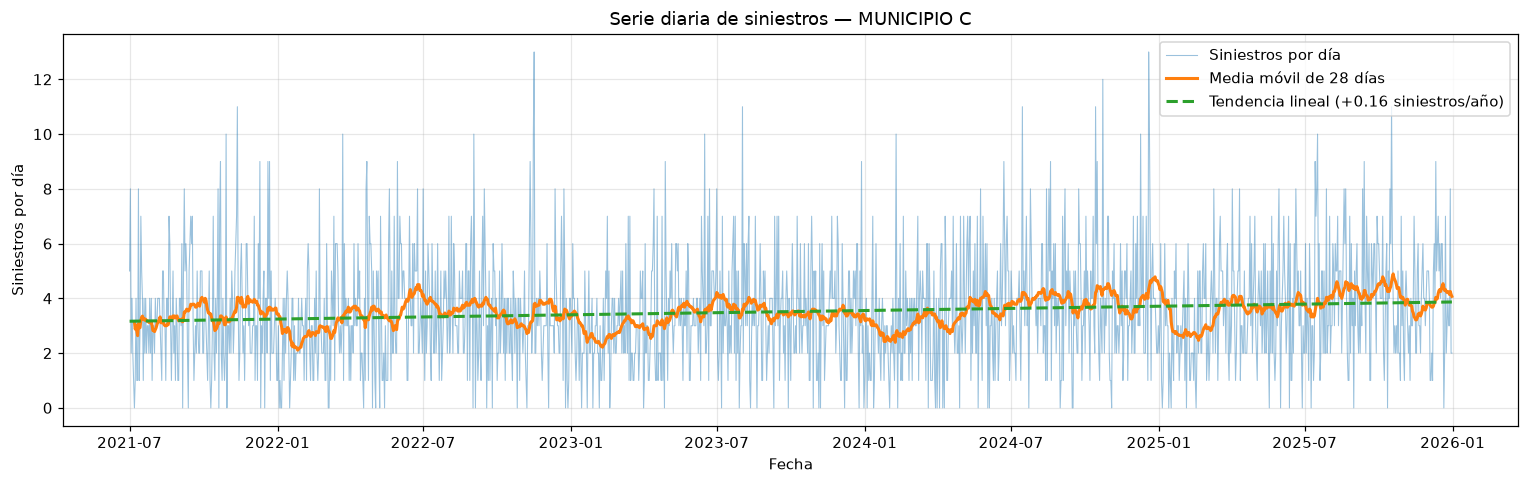

In [8]:
y = serie_df["n_siniestros"].astype(float)
t_idx = np.arange(len(y))
pend, orig = np.polyfit(t_idx, y.values, 1)
tendencia = np.polyval((pend, orig), t_idx)
mm28 = y.rolling(28, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(y.index, y.values, lw=0.7, alpha=0.45, label="Siniestros por día")
ax.plot(y.index, mm28.values, lw=2, label="Media móvil de 28 días")
ax.plot(y.index, tendencia, lw=2, ls="--",
        label=f"Tendencia lineal ({pend * 365:+.2f} siniestros/año)")
ax.set_title(f"Serie diaria de siniestros — {serie_df['zona_id'].iloc[0]}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Siniestros por día")
ax.legend()
fig.tight_layout()
guardar_figura(fig, "fig1_serie.png")
plt.show()

  guardado: experiments\linea_base\tablas\02_perfil_calendario.csv (3 filas)
  guardado: experiments\linea_base\figuras\fig2_perfil_calendario.png


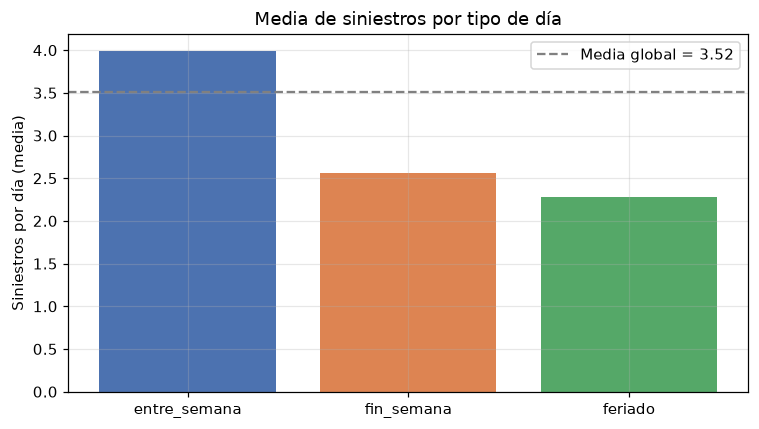

,tipo_dia,dias,media,desvio,factor_vs_global
0,entre_semana,1114,3.988,2.108,1.134
1,fin_semana,454,2.564,1.755,0.729
2,feriado,77,2.286,1.494,0.650


In [9]:
ORDEN_TIPODIA = ["entre_semana", "fin_semana", "feriado"]
perfil_cal = (serie_df.groupby("tipo_dia")["n_siniestros"]
              .agg(dias="count", media="mean", desvio="std")
              .reindex(ORDEN_TIPODIA)
              .reset_index())
perfil_cal["media"] = perfil_cal["media"].round(3)
perfil_cal["desvio"] = perfil_cal["desvio"].round(3)
perfil_cal["factor_vs_global"] = (perfil_cal["media"] / y.mean()).round(3)
guardar_tabla(perfil_cal, "02_perfil_calendario.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(perfil_cal["tipo_dia"], perfil_cal["media"], color=["#4C72B0", "#DD8452", "#55A868"])
ax.axhline(y.mean(), color="gray", ls="--", label=f"Media global = {y.mean():.2f}")
ax.set_title("Media de siniestros por tipo de día")
ax.set_ylabel("Siniestros por día (media)")
ax.legend()
fig.tight_layout()
guardar_figura(fig, "fig2_perfil_calendario.png")
plt.show()
perfil_cal

## 3. Métricas del protocolo

Igual que `base.ipynb`: desvianza de Poisson media como métrica **principal**, más MAE,
RMSE, razón total predicho/observado, sesgo medio, y días con predicción exactamente
cero (esta última se agrega respecto de `base.ipynb`, porque `base_2.ipynb` la usaba
para leer el comportamiento del árbol y es parte de las métricas que pide unificar esta
tarea).

In [10]:
EPS = 1e-6  # la desvianza de Poisson exige predicciones estrictamente positivas


def evaluar(y_true, y_pred):
    "Devuelve el diccionario de métricas del protocolo para un tramo."
    y_true = np.asarray(y_true, dtype=float)
    y_pred_crudo = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred_crudo, EPS, None)
    return {
        "desvianza_poisson": mean_poisson_deviance(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "razon_total": float(y_pred.sum() / y_true.sum()),
        "sesgo_medio": float(np.mean(y_pred - y_true)),
        "dias_prediccion_cero": int(np.sum(y_pred_crudo == 0)),
        "n_dias": int(len(y_true)),
    }


_chk = evaluar([1, 2, 3, 4], [1, 2, 3, 4])
print("desvianza de una predicción perfecta:", round(_chk["desvianza_poisson"], 8))

desvianza de una predicción perfecta: 0.0


## 4. Partición temporal: entrenamiento inicial, validación y prueba

Igual que `base.ipynb`: tres bloques cronológicos consecutivos. **Desarrollo** (80 %) se
divide en un tramo de **entrenamiento inicial** (75 % de desarrollo) y un tramo de
**validación por ventana deslizante** (25 % restante). La **prueba** (20 % final) se
reserva: no se usa para calcular medias, elegir ventanas ni comparar modelos hasta la
sección 8. Se toca una sola vez.

In [11]:
HORIZONTE = 7   # días que se predicen en cada corte (horizonte operativo semanal)
PASO = 7        # separación entre orígenes: cortes de validación no solapados
FRAC_TEST = 0.20
FRAC_ENTREN_INICIAL = 0.75

n_total = len(serie_df)
n_test = int(round(n_total * FRAC_TEST))
corte_test = n_total - n_test

serie_desarrollo = serie_df.iloc[:corte_test].copy()
serie_test = serie_df.iloc[corte_test:].copy()   # RESERVADO — no se usa hasta la sección 8

INICIAL = int(round(len(serie_desarrollo) * FRAC_ENTREN_INICIAL))
n_validacion = len(serie_desarrollo) - INICIAL
n_folds_estimado = int(np.ceil(n_validacion / PASO))

particiones = pd.DataFrame({
    "bloque": ["entrenamiento inicial", "validación (ventana deslizante)", "prueba (reservado)"],
    "desde": [serie_desarrollo.index[0].date(),
              serie_desarrollo.index[INICIAL].date(),
              serie_test.index[0].date()],
    "hasta": [serie_desarrollo.index[INICIAL - 1].date(),
              serie_desarrollo.index[-1].date(),
              serie_test.index[-1].date()],
    "dias": [INICIAL, n_validacion, len(serie_test)],
    "pct": [round(100 * INICIAL / n_total, 1),
            round(100 * n_validacion / n_total, 1),
            round(100 * len(serie_test) / n_total, 1)],
})
guardar_tabla(particiones, "03_particiones.csv")
print("Horizonte:", HORIZONTE, "días | Paso:", PASO, "días | Folds de validación estimados:", n_folds_estimado)
particiones

  guardado: experiments\linea_base\tablas\03_particiones.csv (3 filas)
Horizonte: 7 días | Paso: 7 días | Folds de validación estimados: 47


,bloque,desde,hasta,dias,pct
0,entrenamiento inicial,2021-07-01,2024-03-13,987,60.0
1,validación (ventana deslizante),2024-03-14,2025-02-05,329,20.0
2,prueba (reservado),2025-02-06,2025-12-31,329,20.0


### Recordatorio operativo

A partir de acá `serie_test` **no aparece** hasta la sección 8. Cualquier media, factor
o parámetro se estima sobre `serie_desarrollo` (o sobre la ventana de entrenamiento de
cada corte).

## 5. Backtesting de ventana deslizante

Misma función que `base.ipynb`: origen móvil, ventana de entrenamiento expansiva. En la
validación interna `ajuste = historia` (se rehace en cada corte); en la evaluación
final del test, `ajuste` queda **fijo** en todo el desarrollo (`ajuste_fijo`, equivale a
`refit=False`). Es la misma llamada para los tres modelos base y para el candidato: sin
eso los resultados no serían comparables.

In [12]:
def backtesting(datos, modelo, inicio, horizonte, paso, ajuste_fijo=None):
    "Backtesting de origen móvil. `modelo(historia, futuro, ajuste) -> array de predicciones`."
    pred = pd.Series(index=datos.index, dtype=float)
    folds = []
    origen = inicio
    while origen < len(datos):
        fin = min(origen + horizonte, len(datos))
        historia = datos.iloc[:origen]
        futuro = datos.iloc[origen:fin]
        ajuste = historia if ajuste_fijo is None else ajuste_fijo
        p = np.asarray(modelo(historia, futuro, ajuste), dtype=float)
        pred.iloc[origen:fin] = p
        folds.append({
            "origen": datos.index[origen].date(),
            "fin": datos.index[fin - 1].date(),
            **evaluar(futuro["n_siniestros"].values, p),
        })
        origen += paso
    return pred, pd.DataFrame(folds)


def resumen_backtest(nombre, datos, pred):
    "Métricas sobre la unión de todos los tramos de validación (predicciones no nulas)."
    mask = pred.notna()
    m = evaluar(datos.loc[mask, "n_siniestros"].values, pred[mask].values)
    return {"modelo": nombre, **m}

## 6. Líneas base

Tres referencias fijas: no se ajustan por búsqueda, marcan el mínimo aceptable.

1. **Media constante.** Predice siempre la media del ajuste. Es el piso: cualquier
   modelo útil tiene que superarlo.
2. **L0 — promedio de las últimas 4 semanas.** Predice el promedio de lo observado 7,
   14, 21 y 28 días antes (los últimos cuatro días iguales de la semana). No tiene
   parámetros que ajustar: usa directamente `historia`, así que "rehacer el ajuste por
   corte" no cambia nada en este modelo — es el comportamiento esperado, no un atajo.
3. **L1 — tasa del municipio × factor de calendario.** Predice la media del ajuste
   **para ese tipo de día** (`entre_semana` / `fin_semana` / `feriado`). Es la forma que
   el diagnóstico recomienda como línea base del proyecto
   (`resumen_diagnostico_datos.md`, §5.3).

In [13]:
def base_media_constante(historia, futuro, ajuste):
    return np.full(len(futuro), ajuste["n_siniestros"].mean())


def base_L0_promedio_4_semanas(historia, futuro, ajuste):
    # Sin parámetros: usa los rezagos observados en `historia`, `ajuste` no interviene.
    vh = historia["n_siniestros"].to_numpy(dtype=float)
    n = len(vh)
    preds = []
    for i in range(len(futuro)):
        p = n + i  # posición del día a predecir, relativa a historia+futuro concatenados
        preds.append((vh[p - 7] + vh[p - 14] + vh[p - 21] + vh[p - 28]) / 4)
    return np.array(preds)


def base_L1_tasa_calendario(historia, futuro, ajuste):
    glob = ajuste["n_siniestros"].mean()
    medias = ajuste.groupby("tipo_dia")["n_siniestros"].mean()
    return futuro["tipo_dia"].map(medias).fillna(glob).to_numpy(dtype=float)


MODELOS_BASE = {
    "Media constante": base_media_constante,
    "L0 (promedio 4 semanas)": base_L0_promedio_4_semanas,
    "L1 (tasa x calendario)": base_L1_tasa_calendario,
}

## 7. Modelo candidato preliminar — árbol de decisión

> **Esto no es una línea base.** Es un modelo que se ajusta con los datos y compite por
> ser la solución. Sus hiperparámetros (`max_depth=4`, `min_samples_leaf=20`) se
> **fijaron a mano**, no por búsqueda; elegirlos por validación interna es trabajo del
> **Entregable 3**. Se presenta en esta sección separada, no junto a las líneas base,
> para que la lectura no confunda una referencia fija con un candidato.

Mismas variables y mismos hiperparámetros que "Árbol B" de `base.ipynb` — sólo cambia
el rótulo (pasa a llamarse **"Árbol candidato (preliminar)"**) y su ubicación en el
notebook:

- **rezagos observados**: `y(t−7)`, `y(t−14)`, `y(t−21)` — conocidos para un horizonte
  de 7 días, sin recursión;
- **calendario**: indicadoras de `fin_semana` y `feriado` (`entre_semana` es la
  referencia);
- **tendencia**: `t_anios`, el tiempo en años desde el inicio.

Un árbol **sin podar** memoriza el ruido del entrenamiento (`base.ipynb` lo mostró:
profundidad 31, 943 hojas, desvianza 12,65 en desarrollo). `max_depth=4,
min_samples_leaf=20` es la configuración mínima para que sea una referencia sensata, no
un resultado de ajuste.

In [14]:
_COLS_ARBOL = ["y_lag7", "y_lag14", "y_lag21", "t_anios", "es_fin_semana", "es_feriado"]

# Configuración fijada a mano (no por búsqueda): ver la nota de la sección 7.
ARBOL_KW = dict(max_depth=4, min_samples_leaf=20, random_state=SEMILLA)


def _fila_features(valores, tipos, p, t0):
    return [valores[p - 7], valores[p - 14], valores[p - 21],
            (p - t0) / 365.25,
            1.0 if tipos[p] == "fin_semana" else 0.0,
            1.0 if tipos[p] == "feriado" else 0.0]


def _matriz_entrenamiento(ajuste):
    va = ajuste["n_siniestros"].to_numpy(dtype=float)
    ta = ajuste["tipo_dia"].to_numpy()
    X = [_fila_features(va, ta, p, 0) for p in range(21, len(va))]
    return np.asarray(X), va[21:]


def _matriz_prediccion(historia, futuro):
    vh = historia["n_siniestros"].to_numpy(dtype=float)
    th = historia["tipo_dia"].to_numpy()
    tf = futuro["tipo_dia"].to_numpy()
    n = len(vh)
    # Los rezagos t-7/14/21 caen todos dentro de `historia` para un horizonte de 7 días.
    tt = np.concatenate([th, tf])
    Xf = []
    for i in range(len(futuro)):
        p = n + i
        Xf.append([vh[p - 7], vh[p - 14], vh[p - 21],
                   p / 365.25,
                   1.0 if tt[p] == "fin_semana" else 0.0,
                   1.0 if tt[p] == "feriado" else 0.0])
    return np.asarray(Xf)


def hacer_modelo_arbol(**kw):
    "Devuelve un `ajustar_predecir` que entrena un DecisionTreeRegressor con la config dada."
    params = {**ARBOL_KW, **kw}

    def ajustar_predecir(historia, futuro, ajuste):
        X, obj = _matriz_entrenamiento(ajuste)
        modelo = DecisionTreeRegressor(**params).fit(X, obj)
        return np.clip(modelo.predict(_matriz_prediccion(historia, futuro)), 0.0, None)

    return ajustar_predecir


NOMBRE_ARBOL = "Arbol candidato (preliminar)"
MODELOS_TODOS = {**MODELOS_BASE, NOMBRE_ARBOL: hacer_modelo_arbol()}

## 8. Validación interna (47 cortes de 7 días)

Corremos los cuatro modelos sobre `serie_desarrollo` con ventana deslizante. El test no
participa.

In [15]:
pred_dev = {}
folds_dev = {}
filas_resumen = []
for nombre, fn in MODELOS_TODOS.items():
    p, f = backtesting(serie_desarrollo, fn, INICIAL, HORIZONTE, PASO)
    pred_dev[nombre] = p
    folds_dev[nombre] = f
    filas_resumen.append({**resumen_backtest(nombre, serie_desarrollo, p), "n_folds": len(f)})

tabla_dev = pd.DataFrame(filas_resumen).sort_values("desvianza_poisson").reset_index(drop=True)
for c in ["desvianza_poisson", "mae", "rmse", "razon_total", "sesgo_medio"]:
    tabla_dev[c] = tabla_dev[c].round(4)
guardar_tabla(tabla_dev, "04_desarrollo_backtesting.csv")

  guardado: experiments\linea_base\tablas\04_desarrollo_backtesting.csv (4 filas)


,modelo,desvianza_poisson,mae,rmse,razon_total,sesgo_medio,dias_prediccion_cero,n_dias,n_folds
0,L1 (tasa x calendario),1.3782,1.6114,2.1641,0.9146,-0.3163,0,329,47
1,Arbol candidato (preliminar),1.3912,1.6789,2.1891,0.9988,-0.0045,0,329,47
2,Media constante,1.5178,1.7591,2.2735,0.9133,-0.3208,0,329,47
3,L0 (promedio 4 semanas),1.6908,1.8792,2.4088,1.0113,0.0418,0,329,47


**Resultados — líneas base (validación interna):**

In [16]:
tabla_dev[tabla_dev["modelo"].isin(MODELOS_BASE)].reset_index(drop=True)

,modelo,desvianza_poisson,mae,rmse,razon_total,sesgo_medio,dias_prediccion_cero,n_dias,n_folds
0,L1 (tasa x calendario),1.3782,1.6114,2.1641,0.9146,-0.3163,0,329,47
1,Media constante,1.5178,1.7591,2.2735,0.9133,-0.3208,0,329,47
2,L0 (promedio 4 semanas),1.6908,1.8792,2.4088,1.0113,0.0418,0,329,47


**Resultado — modelo candidato preliminar (validación interna):**

In [17]:
tabla_dev[tabla_dev["modelo"] == NOMBRE_ARBOL].reset_index(drop=True)

,modelo,desvianza_poisson,mae,rmse,razon_total,sesgo_medio,dias_prediccion_cero,n_dias,n_folds
0,Arbol candidato (preliminar),1.3912,1.6789,2.1891,0.9988,-0.0045,0,329,47


  guardado: experiments\linea_base\figuras\fig3_desarrollo_predicciones.png


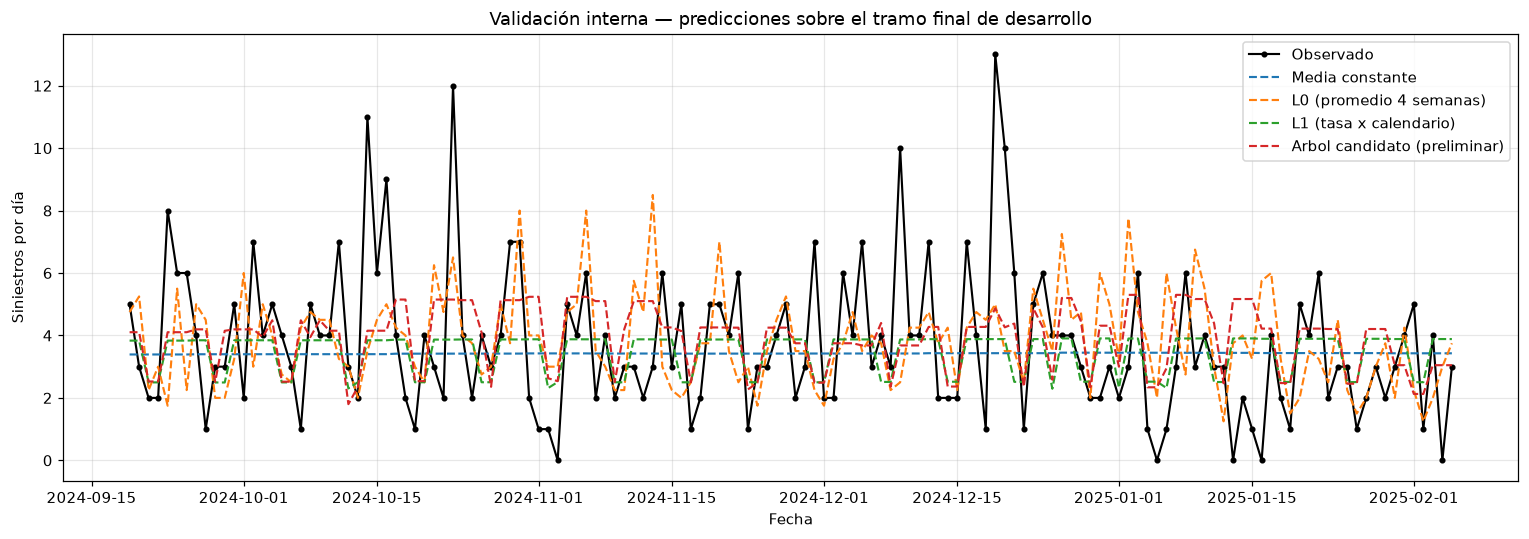

In [18]:
# Predicciones de los últimos ~140 días de desarrollo, para ver el comportamiento.
ventana_fig = serie_desarrollo.index[-140:]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ventana_fig, serie_desarrollo.loc[ventana_fig, "n_siniestros"],
        color="black", lw=1.4, marker="o", ms=3, label="Observado")
for nombre in MODELOS_TODOS:
    ax.plot(ventana_fig, pred_dev[nombre].loc[ventana_fig], lw=1.4, ls="--", label=nombre)
ax.set_title("Validación interna — predicciones sobre el tramo final de desarrollo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Siniestros por día")
ax.legend()
fig.tight_layout()
guardar_figura(fig, "fig3_desarrollo_predicciones.png")
plt.show()

## 9. Por qué se retiran los otros dos modelos del Entregable 2

Del panorama original de seis modelos, estos dos **no pasan** a este notebook (quedan
preservados, con sus artefactos completos, en la rama `entregable_2`):

- **"Repetir semana anterior" (naive estacional).** Desvianza de Poisson **5,007** en el
  conjunto de prueba completo (`experiments/base_2/tablas/05_test_metricas.csv`, rama
  `entregable_2`) — el peor desempeño de los seis modelos evaluados en el Entregable 2.
  Ya cumplió su función como referencia negativa: mostrar que copiar un solo día pasado
  es una predicción demasiado ruidosa. No aporta más si se mantiene.
- **"Árbol A"** (`base_2.ipynb`, `DecisionTreeRegressor(max_depth=15)` con
  `skforecast.ForecasterRecursive`, rezagos `[1, 7, 14, 21]`). **716 hojas para 1.295
  filas de entrenamiento** (`experiments/base_2/tablas/02_tamano_arbol.csv`, rama
  `entregable_2`): en promedio 1,81 días por hoja, memorización, no aprendizaje de
  reglas generales. No tuvo validación interna — se evaluó directamente contra el test,
  sin ningún corte de desarrollo. Reajustar sus hiperparámetros no corrige el problema
  de fondo (falta de validación); es un rediseño, y eso es Entregable 3.

El **"Árbol candidato (preliminar)"** de este notebook es "Árbol B" de `base.ipynb":
mismos hiperparámetros y variables, sólo cambia el rótulo y la sección donde aparece
(ver §7).

## 10. Evaluación final sobre el conjunto de prueba

Ahora —y sólo ahora— se usa `serie_test`. El ajuste queda **congelado** en el
desarrollo (`ajuste_fijo=serie_desarrollo`); sólo la historia para los rezagos avanza a
medida que pasan los días, como ocurriría en operación. Se evalúan los cuatro modelos
—las tres líneas base y el candidato preliminar, todos con el mismo protocolo— para que
la comparación final sea posible. Esto no cambia el estatus del árbol: sigue siendo un
candidato preliminar, no una línea base, aunque aparezca en la misma tabla de
resultados.

Este resultado se reporta una sola vez y no se vuelve atrás a cambiar nada en función
de él.

In [19]:
serie_total = pd.concat([serie_desarrollo, serie_test])
inicio_test = len(serie_desarrollo)

pred_test = {}
filas_test = []
for nombre, fn in MODELOS_TODOS.items():
    p, f = backtesting(serie_total, fn, inicio_test, HORIZONTE, PASO,
                       ajuste_fijo=serie_desarrollo)
    pred_test[nombre] = p.iloc[inicio_test:]
    filas_test.append({**resumen_backtest(nombre, serie_total, p), "n_folds": len(f)})

tabla_test = pd.DataFrame(filas_test).sort_values("desvianza_poisson").reset_index(drop=True)
for c in ["desvianza_poisson", "mae", "rmse", "razon_total", "sesgo_medio"]:
    tabla_test[c] = tabla_test[c].round(4)
guardar_tabla(tabla_test, "05_evaluacion_test.csv")
tabla_test

  guardado: experiments\linea_base\tablas\05_evaluacion_test.csv (4 filas)


,modelo,desvianza_poisson,mae,rmse,razon_total,sesgo_medio,dias_prediccion_cero,n_dias,n_folds
0,L1 (tasa x calendario),1.0848,1.5919,1.9667,0.8841,-0.4493,0,329,47
1,Media constante,1.2625,1.7411,2.1199,0.8839,-0.4498,0,329,47
2,L0 (promedio 4 semanas),1.3324,1.7546,2.1791,0.9810,-0.0737,0,329,47
3,Arbol candidato (preliminar),1.6789,1.9055,2.4087,0.7229,-1.0737,0,329,47


  guardado: experiments\linea_base\figuras\fig4_test_predicciones.png


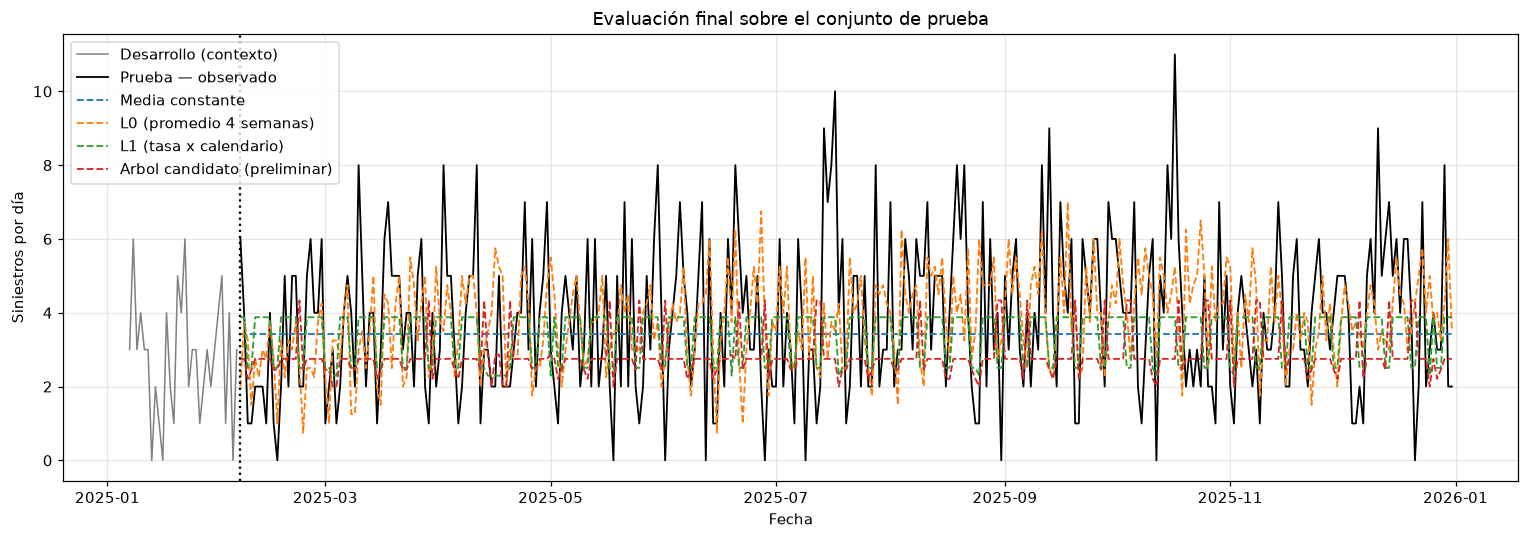

In [20]:
# Figura: observado vs los cuatro modelos en el test, con 30 días de contexto.
ctx = serie_desarrollo.index[-30:]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ctx, serie_desarrollo.loc[ctx, "n_siniestros"], color="gray", lw=1, label="Desarrollo (contexto)")
ax.plot(serie_test.index, serie_test["n_siniestros"], color="black", lw=1.2, label="Prueba — observado")
for nombre in MODELOS_TODOS:
    ax.plot(serie_test.index, pred_test[nombre], lw=1.2, ls="--", label=nombre)
ax.axvline(serie_test.index[0], color="black", ls=":")
ax.set_title("Evaluación final sobre el conjunto de prueba")
ax.set_xlabel("Fecha")
ax.set_ylabel("Siniestros por día")
ax.legend()
fig.tight_layout()
guardar_figura(fig, "fig4_test_predicciones.png")
plt.show()

## 11. Celda de no regresión

Compara los resultados recién calculados contra los que ya se habían obtenido, por
separado, en `base.ipynb` y `base_2.ipynb` (rama `entregable_2`), copiados a
`experiments/linea_base/referencia_no_regresion.csv` antes de que esos notebooks se
retiraran de `main`. Reemplaza el control cruzado que existía cuando había dos
notebooks calculando la media constante por separado.

Compara con una tolerancia de 0,001 (no igualdad exacta de floats: la referencia de L0
sólo tiene 3 decimales en su fuente). Si alguna cifra no coincide, **detiene la
ejecución** — no se ajusta el valor esperado: una diferencia significaría que la
unificación cambió algo.

In [21]:
RUTA_REFERENCIA = DIR_EXPERIMENTO / "referencia_no_regresion.csv"
referencia = pd.read_csv(RUTA_REFERENCIA).set_index("modelo")

NOMBRES_REFERENCIA = {
    "Media constante": "media_constante",
    "L0 (promedio 4 semanas)": "L0",
    "L1 (tasa x calendario)": "L1",
    NOMBRE_ARBOL: "arbol_candidato",
}

TOLERANCIA = 1e-3
tabla_test_idx = tabla_test.set_index("modelo")
_errores_regresion = []
for _nombre_modelo, _clave_ref in NOMBRES_REFERENCIA.items():
    _fila_actual = tabla_test_idx.loc[_nombre_modelo]
    _fila_ref = referencia.loc[_clave_ref]
    for _metrica, _col in [("desvianza_poisson", "desvianza_poisson"), ("mae", "mae")]:
        _actual = float(_fila_actual[_col])
        _esperado = float(_fila_ref[_metrica])
        _dif = abs(_actual - _esperado)
        if _dif > TOLERANCIA:
            _errores_regresion.append(
                f"{_nombre_modelo} / {_metrica}: esperado {_esperado:.4f}, "
                f"obtenido {_actual:.4f} (diferencia {_dif:.4f})"
            )

if _errores_regresion:
    _mensaje = ("La unificación cambió resultados respecto de base.ipynb / base_2.ipynb "
                "(rama entregable_2):\n  - " + "\n  - ".join(_errores_regresion))
    raise AssertionError(_mensaje)

print(f"No regresión OK — {len(NOMBRES_REFERENCIA)} modelos coinciden con "
      f"experiments/linea_base/referencia_no_regresion.csv (tolerancia {TOLERANCIA}).")
for _nombre_modelo, _clave_ref in NOMBRES_REFERENCIA.items():
    _fila_actual = tabla_test_idx.loc[_nombre_modelo]
    print(f"  {_nombre_modelo:32s} desvianza {_fila_actual['desvianza_poisson']:.4f}  "
          f"mae {_fila_actual['mae']:.4f}")

No regresión OK — 4 modelos coinciden con experiments/linea_base/referencia_no_regresion.csv (tolerancia 0.001).
  Media constante                  desvianza 1.2625  mae 1.7411
  L0 (promedio 4 semanas)          desvianza 1.3324  mae 1.7546
  L1 (tasa x calendario)           desvianza 1.0848  mae 1.5919
  Arbol candidato (preliminar)     desvianza 1.6789  mae 1.9055


## 12. Interpretación de los resultados

- **Con la métrica principal en el test, L1 (tasa × calendario) es la mejor** de los
  cuatro (`05_evaluacion_test.csv`). Sigue siendo la línea base recomendada del
  proyecto, igual que en `base.ipynb`.
- **El árbol candidato preliminar es el peor de los cuatro en el test**, aunque haya
  sido competitivo en desarrollo: no extrapola la tendencia creciente de la serie
  (`t_anios` cae fuera del rango de entrenamiento) e infra-predice más que las líneas
  base. El protocolo hizo su trabajo — un modelo que parecía razonable en validación se
  cae en la prueba reservada.
- **L0 no es la referencia de menor desvianza**: la media constante le gana. No se
  cambia acá — revisarlo con datos de validación, no con el test, queda para el
  Entregable 3 (ver `documentacion/cambios_para_informe.md`).

### Limitaciones y lo que NO puede afirmarse

- **Es una sola serie.** MUNICIPIO C no representa al proyecto. Estas cifras no son las
  del sistema: la evaluación desagregada por municipio es el trabajo del notebook del
  panel.
- **El árbol candidato es un modelo de arranque, no ajustado.** `max_depth=4` se fijó a
  mano; la selección de modelo e hiperparámetros es el Entregable 3.
- **El clima y el rezago de 1 día no se usan.** Quedan como candidatos para el panel.

**Frases que no deben aparecer en el informe a partir de este notebook:**

- ❌ «El árbol candidato es el modelo final del proyecto.» → es un modelo de arranque
  preliminar; la selección de modelo es el Entregable 3.
- ❌ «MUNICIPIO C es el más peligroso.» → es el que más siniestros **registra**.
- ❌ «El modelo generaliza / funciona bien en Montevideo.» → se evaluó una sola serie.

## 13. Índice de artefactos

In [22]:
indice = pd.DataFrame([
    ("tablas/00_entorno.csv", "Versiones efectivas de la corrida (§0)"),
    ("tablas/01_serie_resumen.csv", "Estadísticos de la serie de MUNICIPIO C (§1)"),
    ("tablas/02_perfil_calendario.csv", "Media por tipo de día y factor vs global (§2)"),
    ("tablas/03_particiones.csv", "Bloques de entrenamiento, validación y prueba (§4)"),
    ("tablas/04_desarrollo_backtesting.csv", "Métricas de los 4 modelos en validación interna (§8)"),
    ("tablas/05_evaluacion_test.csv", "Métricas de los 4 modelos en el test reservado (§10)"),
    ("referencia_no_regresion.csv", "Valores de referencia de base.ipynb / base_2.ipynb (§11)"),
    ("figuras/fig1_serie.png", "Serie diaria, media móvil y tendencia (§2)"),
    ("figuras/fig2_perfil_calendario.png", "Media por tipo de día (§2)"),
    ("figuras/fig3_desarrollo_predicciones.png", "Predicciones en el tramo final de desarrollo (§8)"),
    ("figuras/fig4_test_predicciones.png", "Observado vs los 4 modelos en el test (§10)"),
], columns=["artefacto", "qué respalda"])
guardar_tabla(indice, "06_artefactos.csv")
indice

  guardado: experiments\linea_base\tablas\06_artefactos.csv (11 filas)


,artefacto,qué respalda
0,tablas/00_entorno.csv,Versiones efectivas de la corrida (§0)
1,tablas/01_serie_resumen.csv,Estadísticos de la serie de MUNICIPIO C (§1)
2,tablas/02_perfil_calendario.csv,Media por tipo de día y factor vs global (§2)
3,tablas/03_particiones.csv,"Bloques de entrenamiento, validación y prueba ..."
4,tablas/04_desarrollo_backtesting.csv,Métricas de los 4 modelos en validación intern...
5,tablas/05_evaluacion_test.csv,Métricas de los 4 modelos en el test reservado...
6,referencia_no_regresion.csv,Valores de referencia de base.ipynb / base_2.i...
7,figuras/fig1_serie.png,"Serie diaria, media móvil y tendencia (§2)"
8,figuras/fig2_perfil_calendario.png,Media por tipo de día (§2)
9,figuras/fig3_desarrollo_predicciones.png,Predicciones en el tramo final de desarrollo (§8)
